In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.chdir('/content/drive/Othercomputers/My Laptop/Work/Grievance Redressal Project')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('data/grievance_dataset_urgency_labels.csv')

In [5]:
df.shape

(37854, 13)

In [6]:
df.columns

Index(['Unnamed: 0', '_id', 'org_code', 'recvd_date', 'closing_date', 'sex',
       'state', 'grievance_text', 'remarks_text', 'grievance_text_processed',
       'yake_keywords', 'textrank_keywords', 'urgency_label'],
      dtype='object')

In [7]:
df.sample(5)

,Unnamed: 0,_id,org_code,recvd_date,closing_date,sex,state,grievance_text,remarks_text,grievance_text_processed,yake_keywords,textrank_keywords,urgency_label
28659,28659,MOLBR/E/2023/0008220,MOLBR,2023-01-24 01:23:16.850000+00:00,2023-01-27 00:00:00+00:00,Male,MH,Labour and Employment >> HR HQ and HR Field\r\...,This office has sent an email to the establis...,labour employment hr hq hr field name address ...,"['chasing email', 'labour employment', 'limite...","['x0x4x5x8x9x8 pf code pf account xxxxx', 'pf ...",high
24859,24859,DOAAC/E/2023/0004175,DOAAC,2023-01-20 16:25:46.947000+00:00,2023-03-06 00:00:00+00:00,Male,KA,Agriculture and Farmers Welfare >> Crop Insura...,No remarks provided,agriculture farmers welfare crop insurance sch...,"['insurance company', 'agriculture farmers', '...","['single rupes insurance company', 'insurance ...",low
13935,13935,CBODT/E/2023/0002310,CBODT,2023-01-11 17:38:04.497000+00:00,2023-01-27 00:00:00+00:00,Female,MH,Central Board of Direct Taxes (Income Tax) >> ...,"As per CPC records for AY 2009-10, jurisdicti...",central board direct taxes income tax direct t...,"['direct taxes', 'assessment year', 'captioned...",['central board direct taxes income tax direct...,medium
19828,19828,DEPOJ/E/2023/0000858,DEPOJ,2023-01-16 23:26:14.457000+00:00,2023-07-14 00:00:00+00:00,Female,MH,Justice >> Access to Justice >> Nyaya Bandhu (...,सोबत जोडलेली पीडीएफ पाहावी.,justice access justice nyaya bandhu probono ad...,"['family members', 'punishable section', 'surg...","['guilty law', 'part innocent truth police', '...",high
6879,6879,DEABD/E/2023/0001506,DEABD,2023-01-06 01:01:10.087000+00:00,2023-01-23 00:00:00+00:00,Male,DN,Financial Services (Banking Division) >> Housi...,Closed,financial services banking division housing lo...,"['rate interest', 'account dashboard', 'housin...","['trap housing loan', 'home loan hdfc', 'priva...",low


In [8]:
# 1. Target Variable
df['recvd_date'] = pd.to_datetime(df['recvd_date'], format='mixed', errors='coerce')
df['closing_date'] = pd.to_datetime(df['closing_date'], format='mixed', errors='coerce')
df['resolution_days'] = (df['closing_date'] - df['recvd_date']).dt.days
df = df[df['resolution_days'] >= 0].copy()

In [9]:
df.shape

(37854, 14)

In [10]:
df.to_csv('data/grievance_dataset_history.csv', index=False)

Text(0, 0.5, 'Frequency')

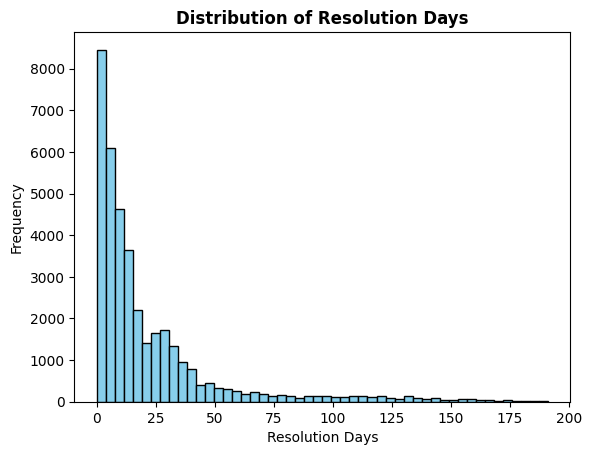

In [ ]:
plt.hist(df['resolution_days'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Resolution Days', fontsize=12, fontweight='bold')
plt.xlabel('Resolution Days')
plt.ylabel('Frequency')


In [ ]:
# !pip install xgboost


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# 2. Feature Engineering & Missing Values
df['recvd_month'] = df['recvd_date'].dt.month

df['grievance_text_processed'] = df['grievance_text_processed'].fillna('')
df['yake_keywords'] = df['yake_keywords'].fillna('')
df['textrank_keywords'] = df['textrank_keywords'].fillna('')
df['org_code'] = df['org_code'].fillna('Unknown')
df['sex'] = df['sex'].fillna('Unknown')
df['state'] = df['state'].fillna('Unknown')

# Feature lists
cat_features = ['org_code', 'sex', 'state']
num_features = ['recvd_month']
text_main = 'grievance_text_processed'
text_yake = 'yake_keywords'
text_tr = 'textrank_keywords'

X = df[[text_main, text_yake, text_tr] + cat_features + num_features]
y = df['resolution_days']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Preprocessing Pipeline with Multiple Text Vectors
preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf_main', TfidfVectorizer(max_features=1500, ngram_range=(1, 2)), text_main),
        ('tfidf_yake', TfidfVectorizer(max_features=500), text_yake),
        ('tfidf_tr', TfidfVectorizer(max_features=500), text_tr),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', StandardScaler(), num_features)
    ])

# 4. Models
models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "XGBoost Regressor": xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# 5. Training and Evaluation
for name, model_instance in models.items():
    print(f"--- Training {name} ---")

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model_instance)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"MAE:  {mae:.2f} days")
    print(f"RMSE: {rmse:.2f} days")
    print(f"R2:   {r2:.4f}\n")

In [ ]:
# --- Training Ridge Regression ---
# MAE:  15.55 days
# RMSE: 24.91 days
# R2:   0.3490

# --- Training XGBoost Regressor ---
# MAE:  14.27 days
# RMSE: 24.24 days
# R2:   0.3834

# --- Training Random Forest ---
# MAE:  13.31 days
# RMSE: 23.70 days
# R2:   0.4106

In [ ]:
df.shape

(37854, 14)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# Feature Engineering & Missing Values
df['recvd_month'] = df['recvd_date'].dt.month

df['grievance_text_processed'] = df['grievance_text_processed'].fillna('')
df['yake_keywords'] = df['yake_keywords'].fillna('')
df['textrank_keywords'] = df['textrank_keywords'].fillna('')
df['org_code'] = df['org_code'].fillna('Unknown')
df['sex'] = df['sex'].fillna('Unknown')
df['state'] = df['state'].fillna('Unknown')

# Feature lists
cat_features = ['org_code', 'sex', 'state']
num_features = ['recvd_month']
text_main = 'grievance_text_processed'
text_yake = 'yake_keywords'
text_tr = 'textrank_keywords'

X = df[[text_main, text_yake, text_tr] + cat_features + num_features]
y = df['resolution_days']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing Pipeline with Multiple Text Vectors
preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf_main', TfidfVectorizer(max_features=1500, ngram_range=(1, 2)), text_main),
        ('tfidf_yake', TfidfVectorizer(max_features=500), text_yake),
        ('tfidf_tr', TfidfVectorizer(max_features=500), text_tr),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', StandardScaler(), num_features)
    ])

# 1. Log-transform the training target
y_train_log = np.log1p(y_train)

print("--- Training XGBoost with Log-Transformed Target ---")

# 2. Build and train the pipeline
pipeline_log = Pipeline(steps=[
    ('preprocessor', preprocessor), # Using the same preprocessor from before
    ('regressor', xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42))
])

pipeline_log.fit(X_train, y_train_log)

# 3. Predict and transform back to normal days
y_pred_log = pipeline_log.predict(X_test)
y_pred_days = np.expm1(y_pred_log)

# 4. Evaluate on the original scale
mae_log = mean_absolute_error(y_test, y_pred_days)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_days))
r2_log = r2_score(y_test, y_pred_days)

print(f"MAE:  {mae_log:.2f} days")
print(f"RMSE: {rmse_log:.2f} days")
print(f"R2:   {r2_log:.4f}")

--- Training XGBoost with Log-Transformed Target ---
MAE:  13.66 days
RMSE: 26.19 days
R2:   0.2803


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# --- 1. Feature Engineering & Missing Values ---
df['recvd_month'] = df['recvd_date'].dt.month

df['grievance_text_processed'] = df['grievance_text_processed'].fillna('')
df['yake_keywords'] = df['yake_keywords'].fillna('')
df['textrank_keywords'] = df['textrank_keywords'].fillna('')
df['org_code'] = df['org_code'].fillna('Unknown')
df['sex'] = df['sex'].fillna('Unknown')
df['state'] = df['state'].fillna('Unknown')

# Feature lists
cat_features = ['org_code', 'sex', 'state']
num_features = ['recvd_month']
text_main = 'grievance_text_processed'
text_yake = 'yake_keywords'
text_tr = 'textrank_keywords'

X = df[[text_main, text_yake, text_tr] + cat_features + num_features]
y = df['resolution_days']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 2. Preprocessing Pipeline ---
preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf_main', TfidfVectorizer(max_features=1500, ngram_range=(1, 2)), text_main),
        ('tfidf_yake', TfidfVectorizer(max_features=500), text_yake),
        ('tfidf_tr', TfidfVectorizer(max_features=500), text_tr),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', StandardScaler(), num_features)
    ])

# --- 3. Log-transform the training target ---
y_train_log = np.log1p(y_train)

print("--- Training GPU-Accelerated XGBoost with Log-Transformed Target ---")

# --- 4. Build and train the pipeline with GPU parameters ---
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=200,          # Increased trees since GPU is faster
    learning_rate=0.1,
    max_depth=6,
    tree_method='hist',        # Required for GPU usage in modern XGBoost
    device='cuda',             # Enables GPU execution
    random_state=42
)

pipeline_log = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb_model)
])

# Fit the model (The TF-IDF runs on CPU, XGBoost runs on GPU)
pipeline_log.fit(X_train, y_train_log)

# --- 5. Predict and transform back to normal days ---
y_pred_log = pipeline_log.predict(X_test)
y_pred_days = np.expm1(y_pred_log)

# --- 6. Evaluate on the original scale ---
mae_log = mean_absolute_error(y_test, y_pred_days)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_days))
r2_log = r2_score(y_test, y_pred_days)

print(f"MAE:  {mae_log:.2f} days")
print(f"RMSE: {rmse_log:.2f} days")
print(f"R2:   {r2_log:.4f}")

--- Training GPU-Accelerated XGBoost with Log-Transformed Target ---
MAE:  13.61 days
RMSE: 26.45 days
R2:   0.2659


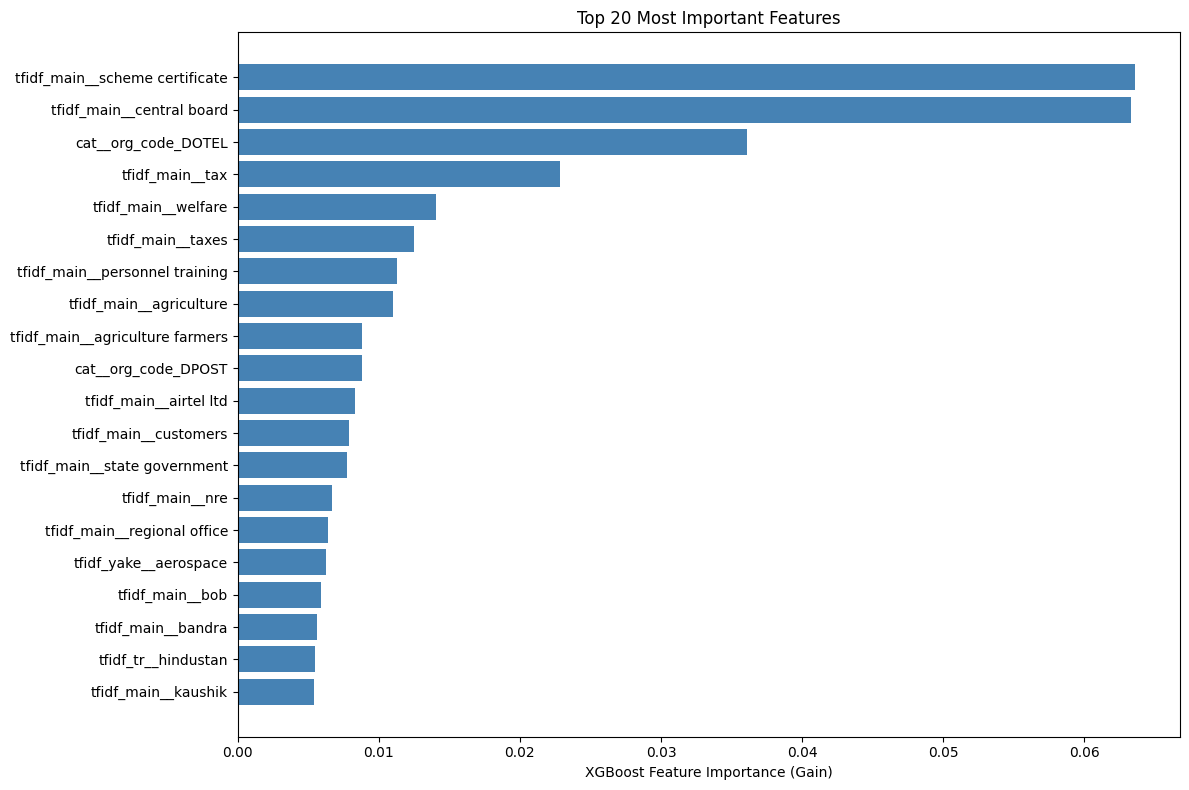

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extract feature names generated by the ColumnTransformer
feature_names = pipeline_log.named_steps['preprocessor'].get_feature_names_out()

# 2. Extract feature importances from the trained XGBoost model
importances = pipeline_log.named_steps['regressor'].feature_importances_

# 3. Combine into a DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 4. Sort to find the most influential features
top_20_features = importance_df.sort_values(by='Importance', ascending=False).head(20)

# 5. Plot the results
plt.figure(figsize=(12, 8))
plt.barh(top_20_features['Feature'][::-1], top_20_features['Importance'][::-1], color='steelblue')
plt.xlabel('XGBoost Feature Importance (Gain)')
plt.title('Top 20 Most Important Features')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# 1. Feature Engineering
df['recvd_date'] = pd.to_datetime(df['recvd_date'])
df['closing_date'] = pd.to_datetime(df['closing_date'])
df['resolution_days'] = (df['closing_date'] - df['recvd_date']).dt.days
df = df[df['resolution_days'] >= 0].copy()

df['recvd_month'] = df['recvd_date'].dt.month

df['grievance_text_processed'] = df['grievance_text_processed'].fillna('')
df['org_code'] = df['org_code'].fillna('Unknown')
df['sex'] = df['sex'].fillna('Unknown')
df['state'] = df['state'].fillna('Unknown')

# 2. Simplified Feature Lists (Dropped YAKE and TextRank)
cat_features = ['org_code', 'sex', 'state']
num_features = ['recvd_month']
text_main = 'grievance_text_processed'

X = df[[text_main] + cat_features + num_features]
y = df['resolution_days']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Streamlined Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        # Increased max_features slightly since we dropped the other text columns
        ('tfidf_main', TfidfVectorizer(max_features=2500, ngram_range=(1, 2)), text_main),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', StandardScaler(), num_features)
    ])

print("--- Training Optimized XGBoost ---")

# 4. Standard XGBoost Model (No Log Transform, GPU Enabled)
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=7,
    tree_method='hist',
    device='cuda',
    random_state=42
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb_model)
])

pipeline.fit(X_train, y_train)

# 5. Evaluate
y_pred = pipeline.predict(X_test)

# Force predictions to be 0 or positive (can't have negative days)
y_pred = np.maximum(0, y_pred)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f} days")
print(f"RMSE: {rmse:.2f} days")
print(f"R2:   {r2:.4f}")

--- Training Optimized XGBoost ---
MAE:  14.26 days
RMSE: 23.98 days
R2:   0.3968


In [ ]:
df = pd.read_csv('data/grievance_data_keyword_extraction.csv')

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# --- 1. Base Feature Engineering ---
df['recvd_date'] = pd.to_datetime(df['recvd_date'], format='mixed', errors='coerce')
df['closing_date'] = pd.to_datetime(df['closing_date'], format='mixed', errors='coerce')
df['resolution_days'] = (df['closing_date'] - df['recvd_date']).dt.days

# Filter out negative days (data entry errors)
df = df[df['resolution_days'] >= 0].copy()

# --- 2. Remove Outliers using IQR (Method 2) ---
Q1 = df['resolution_days'].quantile(0.25)
Q3 = df['resolution_days'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

# Store original size for logging
original_size = len(df)

# Filter the dataframe to keep only normal resolution times
df = df[df['resolution_days'] <= upper_bound].copy()

print(f"Removed outliers above {upper_bound:.2f} days.")
print(f"Dataset size reduced from {original_size} to {len(df)} rows.\n")

# --- 3. Missing Values & Feature Extraction ---
df['recvd_month'] = df['recvd_date'].dt.month
df['grievance_text_processed'] = df['grievance_text_processed'].fillna('')
df['org_code'] = df['org_code'].fillna('Unknown')
df['sex'] = df['sex'].fillna('Unknown')
df['state'] = df['state'].fillna('Unknown')

cat_features = ['org_code', 'sex', 'state']
num_features = ['recvd_month']
text_main = 'grievance_text_processed'

X = df[[text_main] + cat_features + num_features]
y = df['resolution_days']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 4. Preprocessing Pipeline ---
preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf_main', TfidfVectorizer(max_features=2500, ngram_range=(1, 2)), text_main),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', StandardScaler(), num_features)
    ])

print("--- Training XGBoost on Cleaned Data ---")

# --- 5. XGBoost Model (GPU Enabled) ---
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=7,
    tree_method='hist',
    device='cuda',
    random_state=42
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb_model)
])

pipeline.fit(X_train, y_train)

# --- 6. Predict and Evaluate ---
y_pred = pipeline.predict(X_test)
y_pred = np.maximum(0, y_pred) # Prevent negative predictions

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f} days")
print(f"RMSE: {rmse:.2f} days")
print(f"R2:   {r2:.4f}")

Removed outliers above 61.50 days.
Dataset size reduced from 37854 to 34608 rows.

--- Training XGBoost on Cleaned Data ---
MAE:  7.86 days
RMSE: 10.66 days
R2:   0.3950


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [10:04:33] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [ ]:
df.shape

(34608, 14)

In [ ]:
df.to_csv('data/final_data.csv')

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import xgboost as xgb
from sklearn.pipeline import Pipeline

# 1. Define the base model with GPU enabled
# We do not set n_estimators, learning_rate, or max_depth here because the search will provide them.
xgb_base = xgb.XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    device='cuda',
    random_state=42
)

# 2. Rebuild the pipeline with the base GPU model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # Make sure your preprocessor from earlier is still in memory
    ('regressor', xgb_base)
])

# 3. Define the parameter grid
param_grid = {
    'regressor__n_estimators': [200, 300, 500],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__max_depth': [5, 7, 9, 11],
    'regressor__subsample': [0.7, 0.8, 1.0],
    'regressor__colsample_bytree': [0.7, 0.8, 1.0]
}

print("--- Starting Hyperparameter Tuning on GPU ---")

# OPTION A: Randomized Search (Fast - ~2 minutes)
# Change n_iter to test more combinations
search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=1 # Keep at 1. The GPU handles the parallelization internally.
)

# OPTION B: Grid Search (All Permutations - ~1 Hour)
# To use this instead, uncomment the lines below and comment out Option A
"""
search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=2,
    n_jobs=1
)
"""

# 4. Run the search
search.fit(X_train, y_train)

print("\n--- Tuning Complete ---")
print(f"Best Parameters: {search.best_params_}\n")

# 5. Evaluate the best model found
best_model = search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
y_pred_tuned = np.maximum(0, y_pred_tuned) # Prevent negative predictions

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"Tuned MAE:  {mae_tuned:.2f} days")
print(f"Tuned RMSE: {rmse_tuned:.2f} days")
print(f"Tuned R2:   {r2_tuned:.4f}")

--- Starting Hyperparameter Tuning on GPU ---
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END regressor__colsample_bytree=0.8, regressor__learning_rate=0.01, regressor__max_depth=9, regressor__n_estimators=500, regressor__subsample=0.7; total time=  55.0s
[CV] END regressor__colsample_bytree=0.8, regressor__learning_rate=0.01, regressor__max_depth=9, regressor__n_estimators=500, regressor__subsample=0.7; total time=  50.4s
[CV] END regressor__colsample_bytree=0.8, regressor__learning_rate=0.01, regressor__max_depth=9, regressor__n_estimators=500, regressor__subsample=0.7; total time=  50.9s
[CV] END regressor__colsample_bytree=0.8, regressor__learning_rate=0.01, regressor__max_depth=5, regressor__n_estimators=200, regressor__subsample=0.7; total time=  10.9s
[CV] END regressor__colsample_bytree=0.8, regressor__learning_rate=0.01, regressor__max_depth=5, regressor__n_estimators=200, regressor__subsample=0.7; total time=  10.4s
[CV] END regressor__colsample_bytree=0

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import xgboost as xgb

print("--- 1. Pre-processing Data (Doing this ONCE) ---")
# Transform the data outside the pipeline
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Define the base model with GPU enabled
xgb_base = xgb.XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    device='cuda',
    random_state=42
)

# Define the parameter grid
# NOTE: Removed the 'regressor__' prefix because we are not using the Pipeline anymore
param_grid = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 7, 9, 11],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

print("\n--- 2. Starting Lightning-Fast GPU Tuning ---")

# Set up the randomized search directly on the model
search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=1
)
# OPTION B: Grid Search (All Permutations - ~1 Hour)
# To use this instead, uncomment the lines below and comment out Option A
"""
search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=2,
    n_jobs=1 # Keep at 1 since XGBoost manages the GPU parallelization
)
"""

# Run the search on the pre-transformed data
search.fit(X_train_transformed, y_train)

print("\n--- Tuning Complete ---")
print(f"Best Parameters: {search.best_params_}\n")

# Evaluate the best model
best_model = search.best_estimator_
y_pred_tuned = best_model.predict(X_test_transformed)
y_pred_tuned = np.maximum(0, y_pred_tuned)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"Tuned MAE:  {mae_tuned:.2f} days")
print(f"Tuned RMSE: {rmse_tuned:.2f} days")
print(f"Tuned R2:   {r2_tuned:.4f}")

--- 1. Pre-processing Data (Doing this ONCE) ---

--- 2. Starting Lightning-Fast GPU Tuning ---
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=9, n_estimators=500, subsample=0.7; total time=  44.8s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=9, n_estimators=500, subsample=0.7; total time=  42.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=9, n_estimators=500, subsample=0.7; total time=  44.4s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=0.7; total time=   3.7s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=0.7; total time=   3.7s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=0.7; total time=   3.8s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=11, n_estimators=200, subsample=1.0; total time=  46.7s
[CV] END colsample_bytree=0.8,

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# --- 1. Base Feature Engineering ---
df['recvd_date'] = pd.to_datetime(df['recvd_date'], format='mixed', errors='coerce')
df['closing_date'] = pd.to_datetime(df['closing_date'], format='mixed', errors='coerce')
df['resolution_days'] = (df['closing_date'] - df['recvd_date']).dt.days

# Filter out negative days (data entry errors)
df = df[df['resolution_days'] >= 0].copy()

# --- 2. Remove Outliers using IQR (Method 2) ---
Q1 = df['resolution_days'].quantile(0.25)
Q3 = df['resolution_days'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

# Store original size for logging
original_size = len(df)

# Filter the dataframe to keep only normal resolution times
df = df[df['resolution_days'] <= upper_bound].copy()

print(f"Removed outliers above {upper_bound:.2f} days.")
print(f"Dataset size reduced from {original_size} to {len(df)} rows.\n")

# --- 3. Missing Values & Feature Extraction ---
df['recvd_month'] = df['recvd_date'].dt.month
df['grievance_text_processed'] = df['grievance_text_processed'].fillna('')
df['org_code'] = df['org_code'].fillna('Unknown')
df['sex'] = df['sex'].fillna('Unknown')
df['state'] = df['state'].fillna('Unknown')

cat_features = ['org_code', 'sex', 'state']
num_features = ['recvd_month']
text_main = 'grievance_text_processed'

X = df[[text_main] + cat_features + num_features]
y = df['resolution_days']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 4. Preprocessing Pipeline ---
preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf_main', TfidfVectorizer(max_features=2500, ngram_range=(1, 2)), text_main),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', StandardScaler(), num_features)
    ])

print("--- Training XGBoost on Cleaned Data ---")

# --- 5. XGBoost Model (GPU Enabled) ---
# --- Tuning Complete ---
# Best Parameters: {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 11, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=11,
    tree_method='hist',
    device='cuda',
    colsample_bytree = 0.8,
    subsample=1.0,
    random_state=42
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb_model)
])

pipeline.fit(X_train, y_train)

# --- 6. Predict and Evaluate ---
y_pred = pipeline.predict(X_test)
y_pred = np.maximum(0, y_pred) # Prevent negative predictions

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f} days")
print(f"RMSE: {rmse:.2f} days")
print(f"R2:   {r2:.4f}")

Removed outliers above 61.50 days.
Dataset size reduced from 37854 to 34608 rows.

--- Training XGBoost on Cleaned Data ---
MAE:  7.61 days
RMSE: 10.53 days
R2:   0.4094


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [10:48:24] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [ ]:
import pickle

# Save the SVM model
model_path = '/content/drive/Othercomputers/My Laptop/Work/Grievance Redressal Project/06-Resolution-Time-Prediction/model/time_predict.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(pipeline, f)

print(f"Model saved successfully to '{model_path}'")

Model saved successfully to '/content/drive/Othercomputers/My Laptop/Work/Grievance Redressal Project/06-Resolution-Time-Prediction/model/time_predict.pkl'
